In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1168, 260) (292, 260)
(1168,) (292,)


In [2]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Modèle entraîné ✓")

Modèle entraîné ✓


In [3]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = rf_model.score(X_test, y_test)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.1002
RMSE : 0.1464
R²   : 0.8851


In [4]:

prix_median_log = y_test.median()


prix_avec_erreur = np.exp(prix_median_log + mae)
prix_sans_erreur = np.exp(prix_median_log)

erreur_dollars = prix_avec_erreur - prix_sans_erreur

print(f"Prix médian estimé : {prix_sans_erreur:,.0f}$")
print(f"Erreur MAE en dollars : {erreur_dollars:,.0f}$")

Prix médian estimé : 154,150$
Erreur MAE en dollars : 16,241$


In [5]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("Modèle entraîné ✓")

Modèle entraîné ✓


In [6]:
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = xgb_model.score(X_test, y_test)

print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

MAE  : 0.0967
RMSE : 0.1452
R²   : 0.8870


In [7]:
prix_median_log = y_test.median()
erreur_dollars_xgb = np.exp(prix_median_log + mae_xgb) - np.exp(prix_median_log)
print(f"Erreur MAE XGBoost en dollars : {erreur_dollars_xgb:,.0f}$")

Erreur MAE XGBoost en dollars : 15,659$


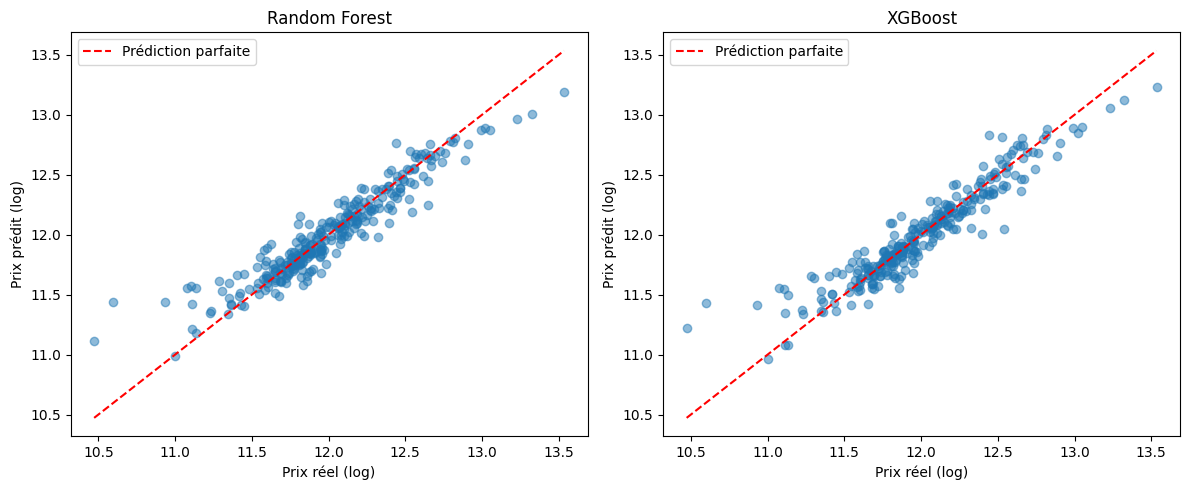

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, 
                              [rf_model.predict(X_test), y_pred_xgb],
                              ['Random Forest', 'XGBoost']):
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', label='Prédiction parfaite')
    ax.set_xlabel('Prix réel (log)')
    ax.set_ylabel('Prix prédit (log)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"Meilleurs paramètres : {grid_search.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


KeyboardInterrupt: 

In [ ]:
xgb_tuned = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)
y_pred_tuned = xgb_tuned.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = root_mean_squared_error(y_test, y_pred_tuned)
r2_tuned = xgb_tuned.score(X_test, y_test)

print("Comparaison des modèles :")
print(f"{'Modèle':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print(f"{'Random Forest':<20} {0.1002:>8.4f} {0.1464:>8.4f} {0.8851:>8.4f}")
print(f"{'XGBoost':<20} {0.0967:>8.4f} {0.1452:>8.4f} {0.8870:>8.4f}")
print(f"{'XGBoost Tuned':<20} {mae_tuned:>8.4f} {rmse_tuned:>8.4f} {r2_tuned:>8.4f}")

Comparaison des modèles :
Modèle                    MAE     RMSE       R²
Random Forest          0.1002   0.1464   0.8851
XGBoost                0.0967   0.1452   0.8870
XGBoost Tuned          0.0895   0.1331   0.9051


In [ ]:
erreur_dollars_tuned = np.exp(prix_median_log + mae_tuned) - np.exp(prix_median_log)
print(f"Erreur MAE XGBoost Tuned : {erreur_dollars_tuned:,.0f}$")

Erreur MAE XGBoost Tuned : 14,435$


In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_tuned, '../models/xgb_champion.pkl')

print("Modèle sauvegardé ✓")

Modèle sauvegardé ✓
